In [13]:
import numpy as np
import matplotlib.pyplot as plt


In [14]:
class Brownian():
    def __init__(self,x0=0):
        assert(type(x0)==float or type(x0)==int or x0 is None)
        self.x0 = float(x0)
    
    def randomwalk(self,n_step=100):
        if n_step<30:
            print("n_step should be at least 30")
        
        w=np.ones(n_step)*self.x0
        for i in range(1,n_step):
            yi=np.random.choice([1,-1])
            w[i]=w[i-1]+(yi/np.sqrt(n_step))
        return w
    def gen_normal(self,n_step=100):
        if n_step<30:
            print("n_step should be at least 30")
        
        w=np.ones(n_step)*self.x0
        for i in range(1,n_step):
            yi=np.random.normal(loc=0,scale=1)
            w[i]=w[i-1]+(yi/np.sqrt(n_step))
        return w
    def stock_price(
                    self,
                    s0=100,
                    mu=0.2,
                    sigma=0.68,
                    deltaT=52,
                    dt=0.1
                    ):
        """
        Models a stock price S(t) using the Weiner process W(t) as
        `S(t) = S(0).exp{(mu-(sigma^2/2).t)+sigma.W(t)}`
        
        Arguments:
            s0: Iniital stock price, default 100
            mu: 'Drift' of the stock (upwards or downwards), default 1
            sigma: 'Volatility' of the stock, default 1
            deltaT: The time period for which the future prices are computed, default 52 (as in 52 weeks)
            dt (optional): The granularity of the time-period, default 0.1
        
        Returns:
            s: A NumPy array with the simulated stock prices over the time-period deltaT
        """
        n_step = int(deltaT/dt)
        time_vector = np.linspace(0,deltaT,num=n_step)
        # Stock variation
        stock_var = (mu-(sigma**2/2))*time_vector
        # Forcefully set the initial value to zero for the stock price simulation
        self.x0=0
        # Weiner process (calls the `gen_normal` method)
        weiner_process = sigma*self.gen_normal(n_step)
        # Add two time series, take exponent, and multiply by the initial stock price
        s = s0*(np.exp(stock_var+weiner_process))
        
        return s

### Process with initial value=0 
using just random walks for data points

In [15]:
b=Brownian()

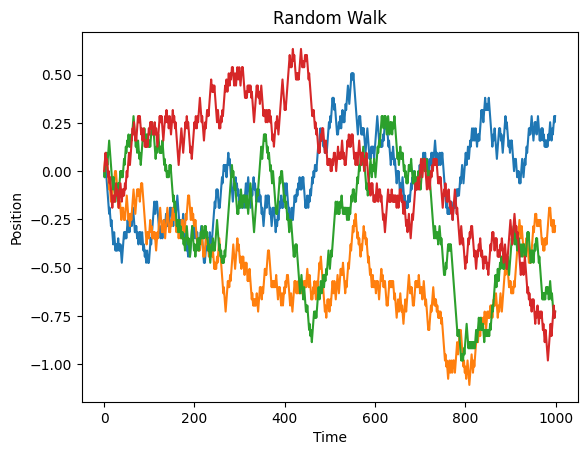

In [17]:
for i in range(4):
    plt.plot(b.randomwalk(1000))

plt.title("Random Walk")
plt.xlabel("Time")
plt.ylabel("Position")
plt.show()

### process with initial value of 20 with normal distribution 


In [18]:
b=Brownian(20)

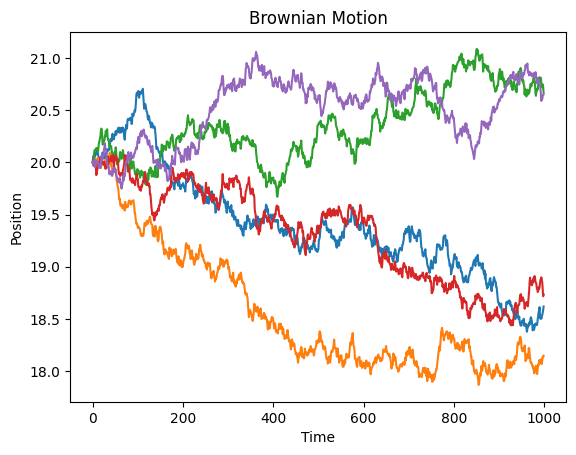

In [19]:
for i in range(5):
    plt.plot(b.gen_normal(1000))
plt.title("Brownian Motion")
plt.xlabel("Time")
plt.ylabel("Position")
plt.show()

### Stock Price Simulation

In [20]:
def plot_stock_price(mu,sigma):
    """
    Plots stock price for multiple scenarios
    """
    plt.figure(figsize=(9,4))
    for i in range(5):
        plt.plot(b.stock_price(mu=mu,
                               sigma=sigma,
                               dt=0.1))
    plt.legend(['Scenario-'+str(i) for i in range(1,6)],
               loc='upper left')
    plt.hlines(y=100,xmin=0,xmax=520,
               linestyle='--',color='k')
    plt.show()

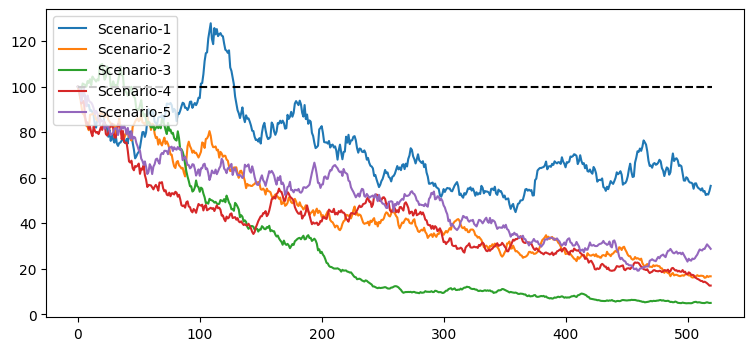

In [21]:
plot_stock_price(mu=0.2,sigma=0.68)

#### changing the volatility 

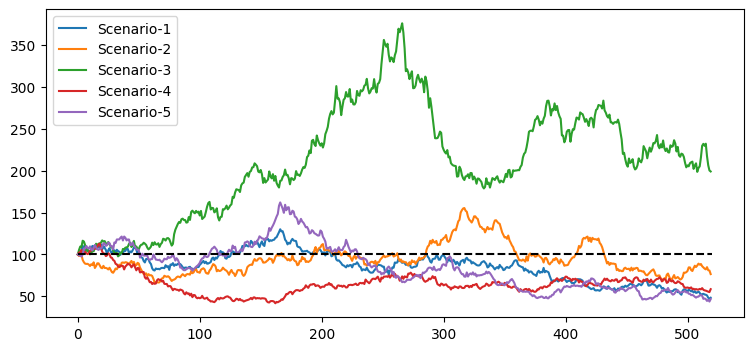

In [22]:
plot_stock_price(mu=0.2,sigma=0.65)

#### lowering the volatility

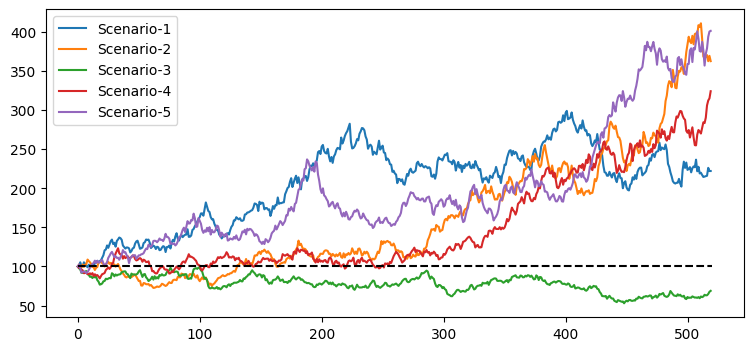

In [23]:
plot_stock_price(mu=0.2,sigma=0.6)

#### 2D plot for brownian motion 

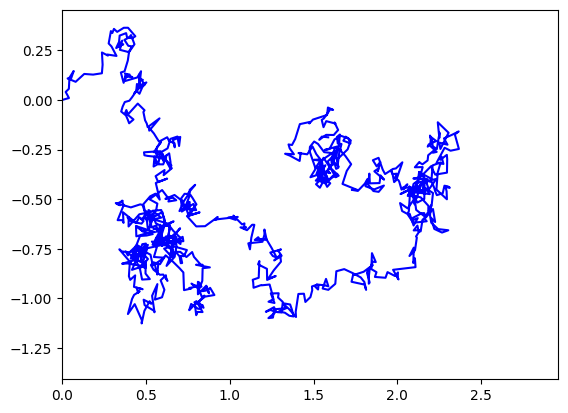

In [24]:
b1 = Brownian()
b2 = Brownian()

x = b1.gen_normal(1000)
y = b2.gen_normal(1000)

plt.plot(x,y,c='b')
xmax,xmin,ymax,ymin = x.max(),x.min(),y.max(),y.min()
scale_factor = 1.25
xmax,xmin,ymax,ymin = xmax*scale_factor,xmin*scale_factor,ymax*scale_factor,ymin*scale_factor
plt.xlim(xmin,xmax)
plt.ylim(ymin,ymax)
plt.show()